In [10]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import svm
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [11]:
df = pd.read_csv(r"E:\my research\algo local\Cardiosense\swat_heart_disease_dataset.csv")

df.drop(columns=['ecg', 'rwma', 'trop', 'angio'], inplace=True)
df.drop_duplicates(inplace=True)

X = df.drop(columns='target')
y = df['target']

In [12]:
transformer = ColumnTransformer(
    transformers=[
        ('age_scaling', MinMaxScaler(), ['age']),

        ('categorical_encoding',
         OneHotEncoder(drop='first'),
         ['sex', 'diabetes', 'fhist']),

        ('cp_encoding',
         OrdinalEncoder(categories=[[
             'No Angina',
             'Stable Angina',
             'Unstable Angina'
         ]]),
         ['cp']),

        ('bp_encoding',
         OrdinalEncoder(categories=[[
             'Normal',
             'Low',
             'High'
         ]]),
         ['BP']),

        ('activity_encoding',
         OrdinalEncoder(categories=[[
             'High',
             'Moderate',
             'Low'
         ]]),
         ['Physical_Activity'])
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [13]:
os.makedirs("SVM", exist_ok=True)

results = []

def run_svm(kernel_name, classifier, param_grid):

    print(f"\n{'=' * 60}")
    print(f"SVM - {kernel_name} Kernel")
    print(f"{'=' * 60}")

    grid = GridSearchCV(
        Pipeline([
            ('transformer', transformer),
            ('scaler', StandardScaler()),
            ('model', svm.SVC())
        ]),
        {'model__' + k: v for k, v in param_grid.items()},
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best Parameters:")
    print(grid.best_params_)

    model = Pipeline([
        ('transformer', transformer),
        ('scaler', StandardScaler()),
        ('classifier', classifier)
    ])

    start_time = time.process_time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    elapsed_time = time.process_time() - start_time

    print(f"Training Time: {elapsed_time:.3f} seconds")

    print(classification_report(y_test, y_pred))

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label='Yes'),
        'Recall': recall_score(y_test, y_pred, pos_label='Yes'),
        'F1 Score': f1_score(y_test, y_pred, pos_label='Yes'),
        'ROC AUC': roc_auc_score(
            (y_test == 'Yes').astype(int),
            (y_pred == 'Yes').astype(int)
        )
    }

    print(f"Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"Precision : {metrics['Precision']:.4f}")
    print(f"Recall    : {metrics['Recall']:.4f}")
    print(f"F1 Score  : {metrics['F1 Score']:.4f}")
    print(f"ROC AUC   : {metrics['ROC AUC']:.4f}")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
    annot_kws={"size": 16}
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{kernel_name} SVM Confusion Matrix')

    plt.tight_layout()

    plt.savefig(
        f"SVM/{kernel_name.lower()}_confusion_matrix.png",
        bbox_inches='tight',
        dpi=150
    )

    print(f"Saved: SVM/{kernel_name.lower()}_confusion_matrix.png")

    plt.show()

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        x=list(metrics.keys()),
        y=list(metrics.values())
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"{kernel_name} SVM Performance")

    plt.tight_layout()

    plt.savefig(
        f"SVM/{kernel_name.lower()}_performance.png",
        bbox_inches='tight',
        dpi=150
    )

    print(f"Saved: SVM/{kernel_name.lower()}_performance.png")

    plt.show()

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf
    )

    results.append({
        'Kernel': kernel_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1 Score': metrics['F1 Score'],
        'ROC AUC': metrics['ROC AUC'],
        'CV Mean': np.mean(cv_scores),
        'CV Std': np.std(cv_scores)
    })

In [14]:

kernels = [
    (
        "Linear",
        svm.SVC(C=0.1, kernel='linear'),
        {
            'C': [0.01, 0.1, 1, 10],
            'kernel': ['linear']
        }
    ),

    (
        "RBF",
        svm.SVC(C=100, kernel='rbf'),
        {
            'C': [0.01, 0.1, 10, 100],
            'gamma': ['scale', 'auto'],
            'kernel': ['rbf']
        }
    ),

    (
        "Poly",
        svm.SVC(C=100, kernel='poly', gamma='scale'),
        {
            'C': [0.01, 0.1, 1, 10],
            'gamma': ['scale'],
            'kernel': ['poly']
        }
    ),

    (
        "Sigmoid",
        svm.SVC(C=100, kernel='sigmoid', gamma='scale'),
        {
            'C': [0.01, 0.1, 1, 10],
            'gamma': ['scale', 'auto'],
            'kernel': ['sigmoid']
        }
    )
]




SVM - Linear Kernel


Best Parameters:
{'model__C': 1, 'model__kernel': 'linear'}
Training Time: 0.016 seconds
              precision    recall  f1-score   support

          No       0.54      0.45      0.49        42
         Yes       0.57      0.65      0.61        46

    accuracy                           0.56        88
   macro avg       0.55      0.55      0.55        88
weighted avg       0.55      0.56      0.55        88

Accuracy  : 0.5568
Precision : 0.5660
Recall    : 0.6522
F1 Score  : 0.6061
ROC AUC   : 0.5523
Saved: SVM/linear_confusion_matrix.png


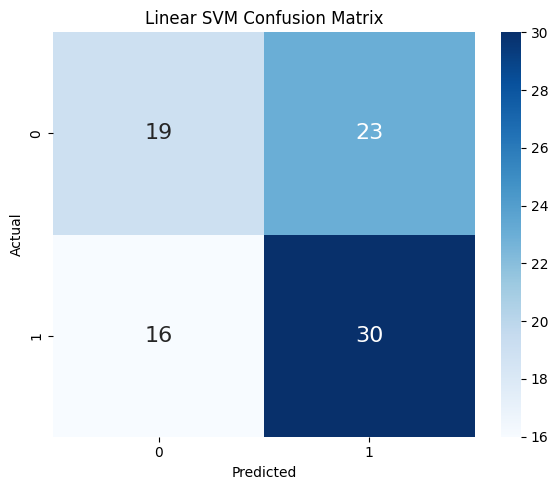

Saved: SVM/linear_performance.png


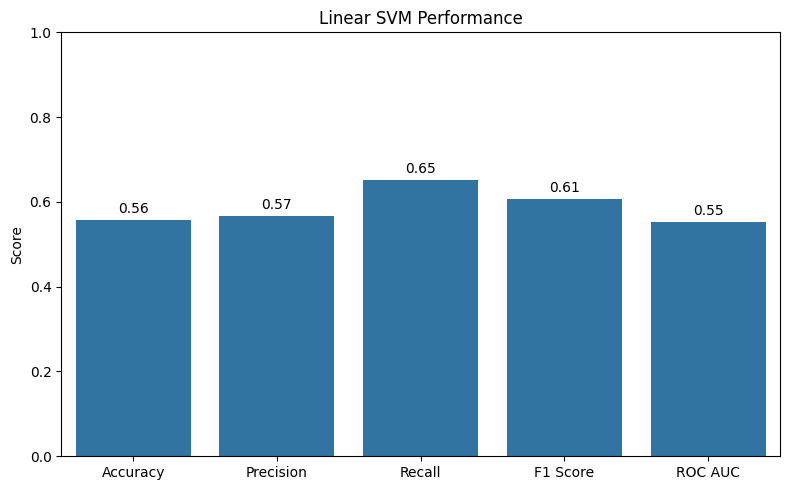


SVM - RBF Kernel
Best Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Training Time: 0.062 seconds
              precision    recall  f1-score   support

          No       0.62      0.50      0.55        42
         Yes       0.61      0.72      0.66        46

    accuracy                           0.61        88
   macro avg       0.61      0.61      0.61        88
weighted avg       0.61      0.61      0.61        88

Accuracy  : 0.6136
Precision : 0.6111
Recall    : 0.7174
F1 Score  : 0.6600
ROC AUC   : 0.6087
Saved: SVM/rbf_confusion_matrix.png


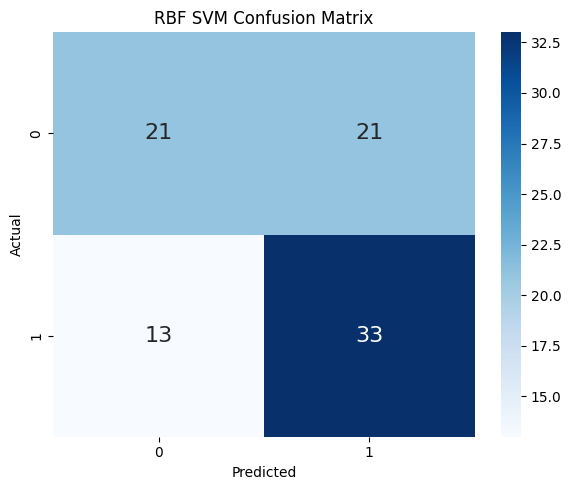

Saved: SVM/rbf_performance.png


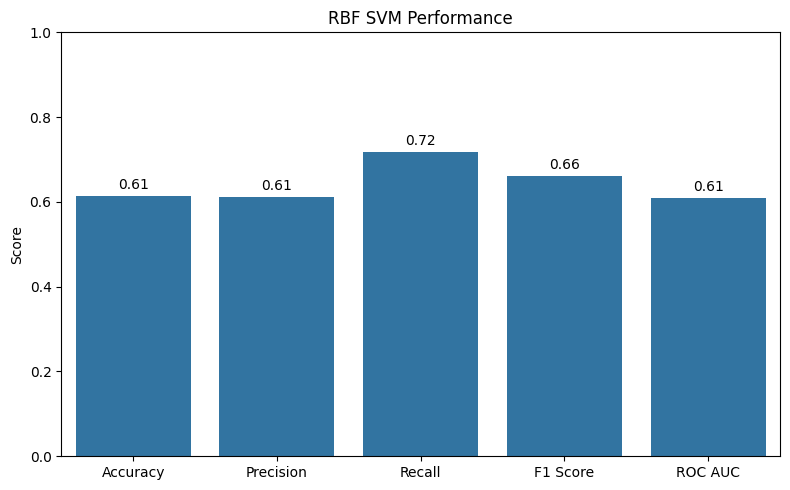


SVM - Poly Kernel
Best Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'poly'}
Training Time: 0.141 seconds
              precision    recall  f1-score   support

          No       0.54      0.52      0.53        42
         Yes       0.57      0.59      0.58        46

    accuracy                           0.56        88
   macro avg       0.56      0.56      0.56        88
weighted avg       0.56      0.56      0.56        88

Accuracy  : 0.5568
Precision : 0.5745
Recall    : 0.5870
F1 Score  : 0.5806
ROC AUC   : 0.5554
Saved: SVM/poly_confusion_matrix.png


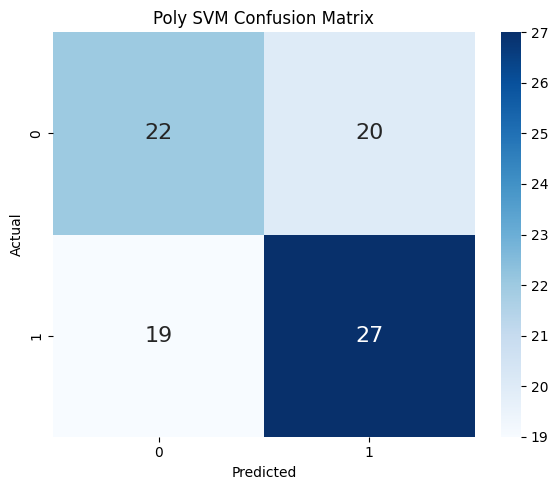

Saved: SVM/poly_performance.png


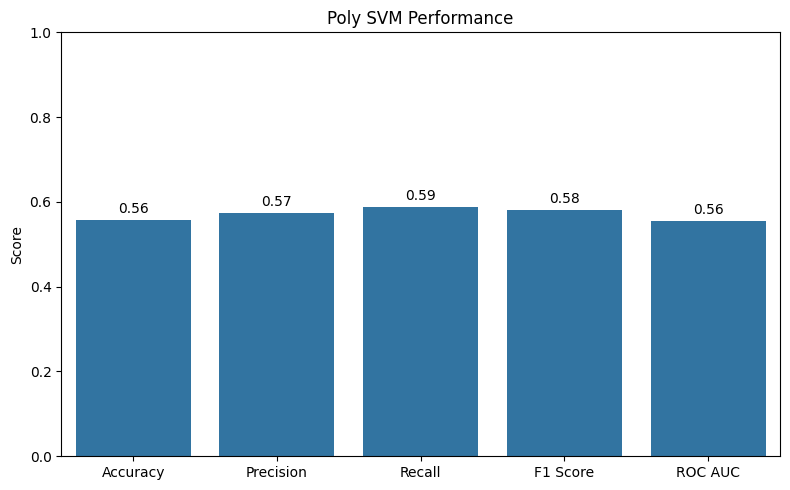


SVM - Sigmoid Kernel
Best Parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'sigmoid'}
Training Time: 0.031 seconds
              precision    recall  f1-score   support

          No       0.60      0.67      0.63        42
         Yes       0.66      0.59      0.62        46

    accuracy                           0.62        88
   macro avg       0.63      0.63      0.62        88
weighted avg       0.63      0.62      0.62        88

Accuracy  : 0.6250
Precision : 0.6585
Recall    : 0.5870
F1 Score  : 0.6207
ROC AUC   : 0.6268
Saved: SVM/sigmoid_confusion_matrix.png


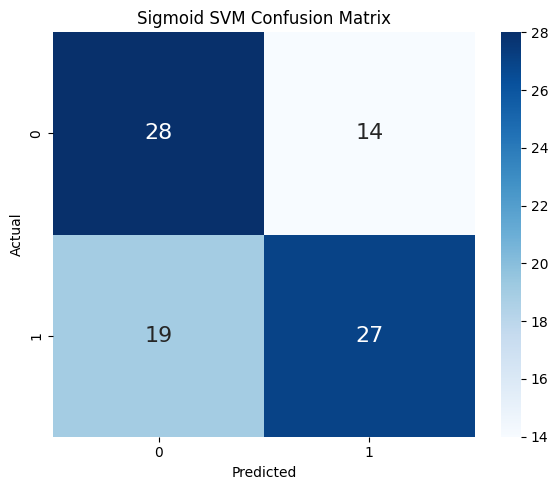

Saved: SVM/sigmoid_performance.png


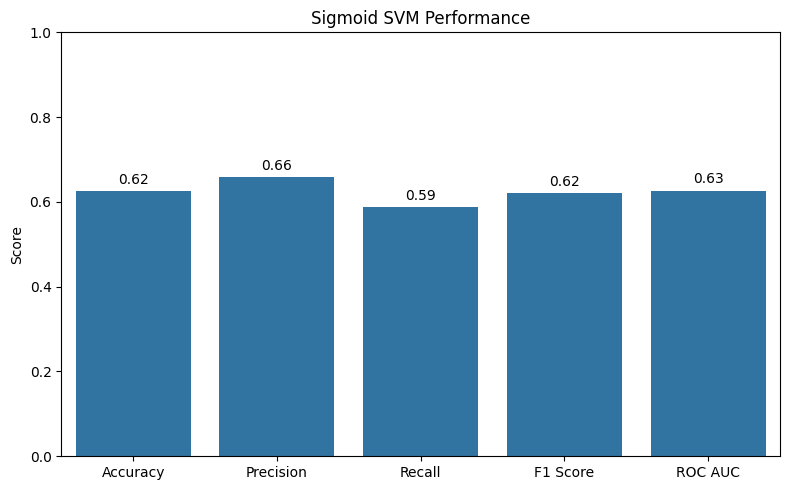

In [15]:
for kernel_name, classifier, param_grid in kernels:
    run_svm(kernel_name, classifier, param_grid)


In [16]:

print("\n" + "=" * 65)
print("SVM MODELS PERFORMANCE SUMMARY")
print("=" * 65)
for result in results:
    print(f"\nKernel      : {result['Kernel']}")
    print(f"Accuracy    : {result['Accuracy']:.4f}")
    print(f"Precision   : {result['Precision']:.4f}")
    print(f"Recall      : {result['Recall']:.4f}")
    print(f"F1 Score    : {result['F1 Score']:.4f}")
    print(f"ROC AUC     : {result['ROC AUC']:.4f}")
    print(f"CV Mean     : {result['CV Mean']:.4f}")
    print(f"CV Std      : {result['CV Std']:.4f}")


SVM MODELS PERFORMANCE SUMMARY

Kernel      : Linear
Accuracy    : 0.5568
Precision   : 0.5660
Recall      : 0.6522
F1 Score    : 0.6061
ROC AUC     : 0.5523
CV Mean     : 0.5826
CV Std      : 0.0721

Kernel      : RBF
Accuracy    : 0.6136
Precision   : 0.6111
Recall      : 0.7174
F1 Score    : 0.6600
ROC AUC     : 0.6087
CV Mean     : 0.5423
CV Std      : 0.0579

Kernel      : Poly
Accuracy    : 0.5568
Precision   : 0.5745
Recall      : 0.5870
F1 Score    : 0.5806
ROC AUC     : 0.5554
CV Mean     : 0.5027
CV Std      : 0.0448

Kernel      : Sigmoid
Accuracy    : 0.6250
Precision   : 0.6585
Recall      : 0.5870
F1 Score    : 0.6207
ROC AUC     : 0.6268
CV Mean     : 0.5344
CV Std      : 0.0554


In [17]:




best_model = max(results, key=lambda x: x['F1 Score'])

print("\n" + "=" * 65)
print("BEST SVM MODEL")
print("=" * 65)

print(f"Kernel      : {best_model['Kernel']}")
print(f"Accuracy    : {best_model['Accuracy']:.4f}")
print(f"F1 Score    : {best_model['F1 Score']:.4f}")
print(f"ROC AUC     : {best_model['ROC AUC']:.4f}")


BEST SVM MODEL
Kernel      : RBF
Accuracy    : 0.6136
F1 Score    : 0.6600
ROC AUC     : 0.6087


In [18]:
#save the best model in .pkl format
import pickle
best_kernel = best_model['Kernel'].lower()
best_classifier = None
if best_kernel == 'linear':
    best_classifier = svm.SVC(C=0.1, kernel='linear')
elif best_kernel == 'rbf':
    best_classifier = svm.SVC(C=100, kernel='rbf', gamma='scale')
elif best_kernel == 'poly':
    best_classifier = svm.SVC(C=100, kernel='poly', gamma='scale')
elif best_kernel == 'sigmoid':
    best_classifier = svm.SVC(C=100, kernel='sigmoid', gamma='scale')
else:
    raise ValueError("Unknown kernel type")

best_model_pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', best_classifier)
])
best_model_pipeline.fit(X_train, y_train)
with open(f"SVM/best_svm_model.pkl", 'wb') as f:
    pickle.dump(best_model_pipeline, f)
print(f"Saved: SVM/best_svm_model.pkl")

Saved: SVM/best_svm_model.pkl
